In [1]:
using Pkg
Pkg.activate("/home/gridsan/aligho/Github_Projects/JJDFTX.jl/")
ENV["JULIA_REVISE_POLL"]="1";
using Revise

In [51]:
using PyPlot, PyCall, Peaks, Statistics, JJDFTX, DelimitedFiles, LinearAlgebra;

In [79]:
# Ions are at (0, 0), (1/3, 2/3), so we have to put centers at (1/6, 1/3), (1/6, -1/6), (-1/3, -1/6)
# The center of the hexagon is at (2/3, 1/3)

In [66]:
Hwannier, cell_map = hwannier("wannier"), np.loadtxt("wannier.map.txt");
lattice_vectors = loadlattice("wannier.out");
kpoints = bandstructkpoints2q(interpolate=20);

In [67]:
qs = norm.(unnormalize_kvector.(Ref(lattice_vectors), kpoints)[1:50]);

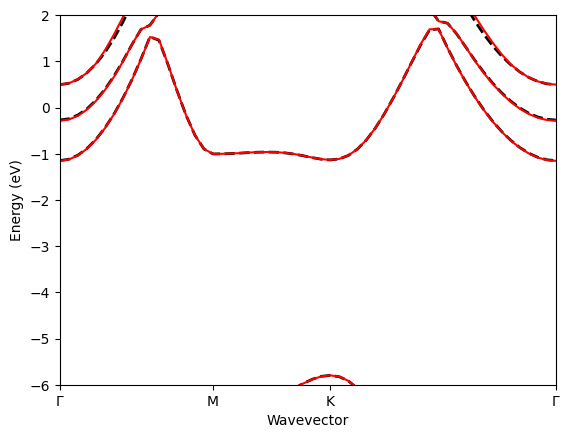

(-6.0, 2.0)

In [14]:
plot_bands("hBN.bands.eigenvals", to_greek=true, linestyle="dashed", color="black", whichbands=[1:7...])

plot_bands(Hwannier, cell_map, kpointsfile="../../Substitutional_Defects/bandstruct.kpoints", color="red")
label_plots()
ylim(-6, 2)

In [69]:
polarizations = []
for (i,k) in enumerate(kpoints[1:50])
    println(i); flush(stdout)
    push!(polarizations, ImΠ(Hwannier, cell_map, lattice_vectors, k, -3, Val(2), histogram_width=10, mesh=10, num_blocks=50, degeneracy=2, monte_carlo=true))
end

1
[0.0, 0.0, 0.0]
2
[0.0014705882353, 0.0, 0.0]
3
[0.0029411764706, 0.0, 0.0]
4
[0.0044117647059, 0.0, 0.0]
5
[0.0058823529412, 0.0, 0.0]
6
[0.0073529411765, 0.0, 0.0]
7
[0.0088235294118, 0.0, 0.0]
8
[0.0102941176471, 0.0, 0.0]
9
[0.0117647058824, 0.0, 0.0]
10
[0.0132352941177, 0.0, 0.0]
11
[0.014705882353, 0.0, 0.0]
12
[0.0161764705883, 0.0, 0.0]
13
[0.0176470588236, 0.0, 0.0]
14
[0.0191176470589, 0.0, 0.0]
15
[0.0205882352942, 0.0, 0.0]
16
[0.0220588235295, 0.0, 0.0]
17
[0.0235294117648, 0.0, 0.0]
18
[0.0250000000001, 0.0, 0.0]
19
[0.0264705882354, 0.0, 0.0]
20
[0.0279411764707, 0.0, 0.0]
21
[0.029411764706, 0.0, 0.0]
22
[0.0308823529413, 0.0, 0.0]
23
[0.0323529411766, 0.0, 0.0]
24
[0.033823529411900005, 0.0, 0.0]
25
[0.0352941176472, 0.0, 0.0]
26
[0.0367647058825, 0.0, 0.0]
27
[0.0382352941178, 0.0, 0.0]
28
[0.039705882353100005, 0.0, 0.0]
29
[0.0411764705884, 0.0, 0.0]
30
[0.0426470588237, 0.0, 0.0]
31
[0.044117647059, 0.0, 0.0]
32
[0.045588235294300006, 0.0, 0.0]
33
[0.04705882352

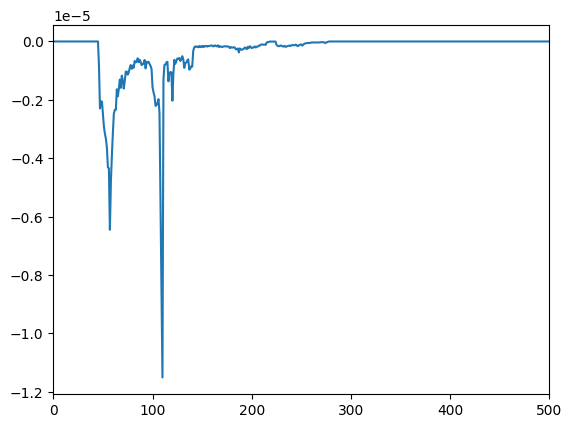

(0.0, 500.0)

In [71]:
plot(smooth(real.(polarizations[2]), win_len=1))
xlim(0, 500)

In [72]:
epsilons_default = zeros(50, 200);
energies = collect(range(0, 100, length=1000))
for (i, k) in enumerate(kpoints[1:50])
    i == 1 && continue
    polarization = polarizations[i]
    for (j, ω) in enumerate(range(0.05, 2, length=200))
        epsilons_default[i, j] = real(ϵ(k, lattice_vectors, ω, energies, smooth(real.(polarization), win_len=10), Val(2), Val(:default), limit=20, δ=0.01, normalized=true))
        #ϵ(k, lattice_vectors, ω, energies, polarizations, δ=0.001, normalized=true)
    end
end

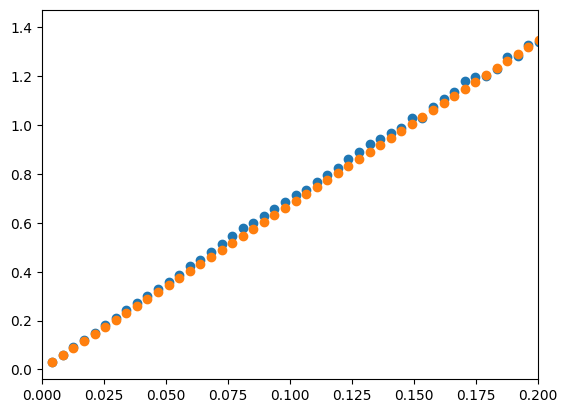

(0.0, 0.2)

In [78]:
scatter(qs[2:end], epsilons_default[2:end, 100] .- 1)
scatter(qs[2:end], 12.69*qs[2:end]*bohrtoangstrom)
xlim(0, 0.2)
#ylim(0, 2)

In [45]:
epsilons_default[:, 20]

50-element Vector{Float64}:
 0.0
 1.1190144630254157
 1.2384008906048505
 1.366389479478535
 1.4672031683972337
 1.574729999734704
 1.7047556846358023
 1.8085924968292044
 1.9479382211233651
 2.030018959587287
 2.0918147420389435
 2.221089746965498
 2.3366034147129318
 ⋮
 3.7301117537205952
 3.6972376525525568
 3.6420376811030923
 3.7471237540012985
 3.7052967333106697
 3.695432298929991
 3.717331476756798
 3.6306835594920255
 3.740961734930267
 3.6922145709919176
 3.680210771182116
 3.6846327469806104

In [46]:
epsilons_default[1, :]

200-element Vector{Float64}:
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 ⋮
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0